# Notebook 13 — Options Lab (Nifty / BankNifty)

**Goal**: Generate options trading signals using Black-Scholes Greeks.

---

## What We Cover

1. **Black-Scholes Model** — option pricing and Greeks
2. **Greeks Visualization** — Delta, Gamma, Theta, Vega surfaces
3. **Implied Volatility** — Newton-Raphson solver
4. **6 Options Strategies** with entry/exit signals:
   - Covered Call
   - Protective Put
   - Bull Call Spread
   - Bear Put Spread
   - Iron Condor
   - Long Straddle

### Black-Scholes Formula

$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$

$$P = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$

Where:
$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

In [9]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from src.options.greeks import BlackScholesGreeks
from src.options.signals import OptionsSignalGenerator
from src.utils.constants import *

plt.style.use("seaborn-v0_8-whitegrid")

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

bs = BlackScholesGreeks()
sig_gen = OptionsSignalGenerator(risk_free_rate=0.065)
print("✅ Setup complete")

✅ Setup complete


## Step 1 — Option Pricing Example

Let's price a Nifty call and put option.

In [10]:
# Nifty current parameters (example)
S = 22500      # Nifty spot price
K = 22500      # At-the-money strike
T = 30 / 365   # 30 days to expiry
r = 0.065      # Risk-free rate (used for parity check below)
sigma = 0.14   # Implied volatility (14%)

call_price = bs.call_price(S, K, T, sigma)
put_price = bs.put_price(S, K, T, sigma)
greeks = bs.all_greeks(S, K, T, sigma)

print(f"╔══════ Nifty ATM Option Pricing ══════╗")
print(f"║  Spot:       ₹{S:>10,}              ║")
print(f"║  Strike:     ₹{K:>10,}              ║")
print(f"║  Expiry:      {T*365:.0f} days               ║")
print(f"║  Volatility:  {sigma:.0%}                  ║")
print(f"╠══════════════════════════════════════╣")
print(f"║  Call Price:  ₹{call_price:>8.2f}             ║")
print(f"║  Put Price:   ₹{put_price:>8.2f}             ║")
print(f"╠══════════ Greeks ═══════════════════╣")
for name, val in greeks.items():
    print(f"║  {name:20s}: {val:>10.6f}    ║")
print(f"╚══════════════════════════════════════╝")

# Put-Call Parity check: C - P = S - K*exp(-rT)
parity_lhs = call_price - put_price
parity_rhs = S - K * np.exp(-r * T)
print(f"\nPut-Call Parity Check: C-P = {parity_lhs:.4f}, S-Ke^(-rT) = {parity_rhs:.4f}")
print(f"Parity holds: {abs(parity_lhs - parity_rhs) < 0.01}")

╔══════ Nifty ATM Option Pricing ══════╗
║  Spot:       ₹    22,500              ║
║  Strike:     ₹    22,500              ║
║  Expiry:      30 days               ║
║  Volatility:  14%                  ║
╠══════════════════════════════════════╣
║  Call Price:  ₹  422.41             ║
║  Put Price:   ₹  302.53             ║
╠══════════ Greeks ═══════════════════╣
║  price               : 422.410000    ║
║  delta               :   0.560900    ║
║  gamma               :   0.000437    ║
║  theta               :  -8.106700    ║
║  vega                :  25.433800    ║
║  rho                 :  10.025100    ║
╚══════════════════════════════════════╝

Put-Call Parity Check: C-P = 119.8850, S-Ke^(-rT) = 119.8850
Parity holds: True


## Step 2 — Delta Surface

**Delta** ($\Delta$) measures how much the option price changes per ₹1 move in the underlying.

- Call delta ∈ [0, 1], Put delta ∈ [-1, 0]
- ATM delta ≈ 0.5 (calls) or -0.5 (puts)

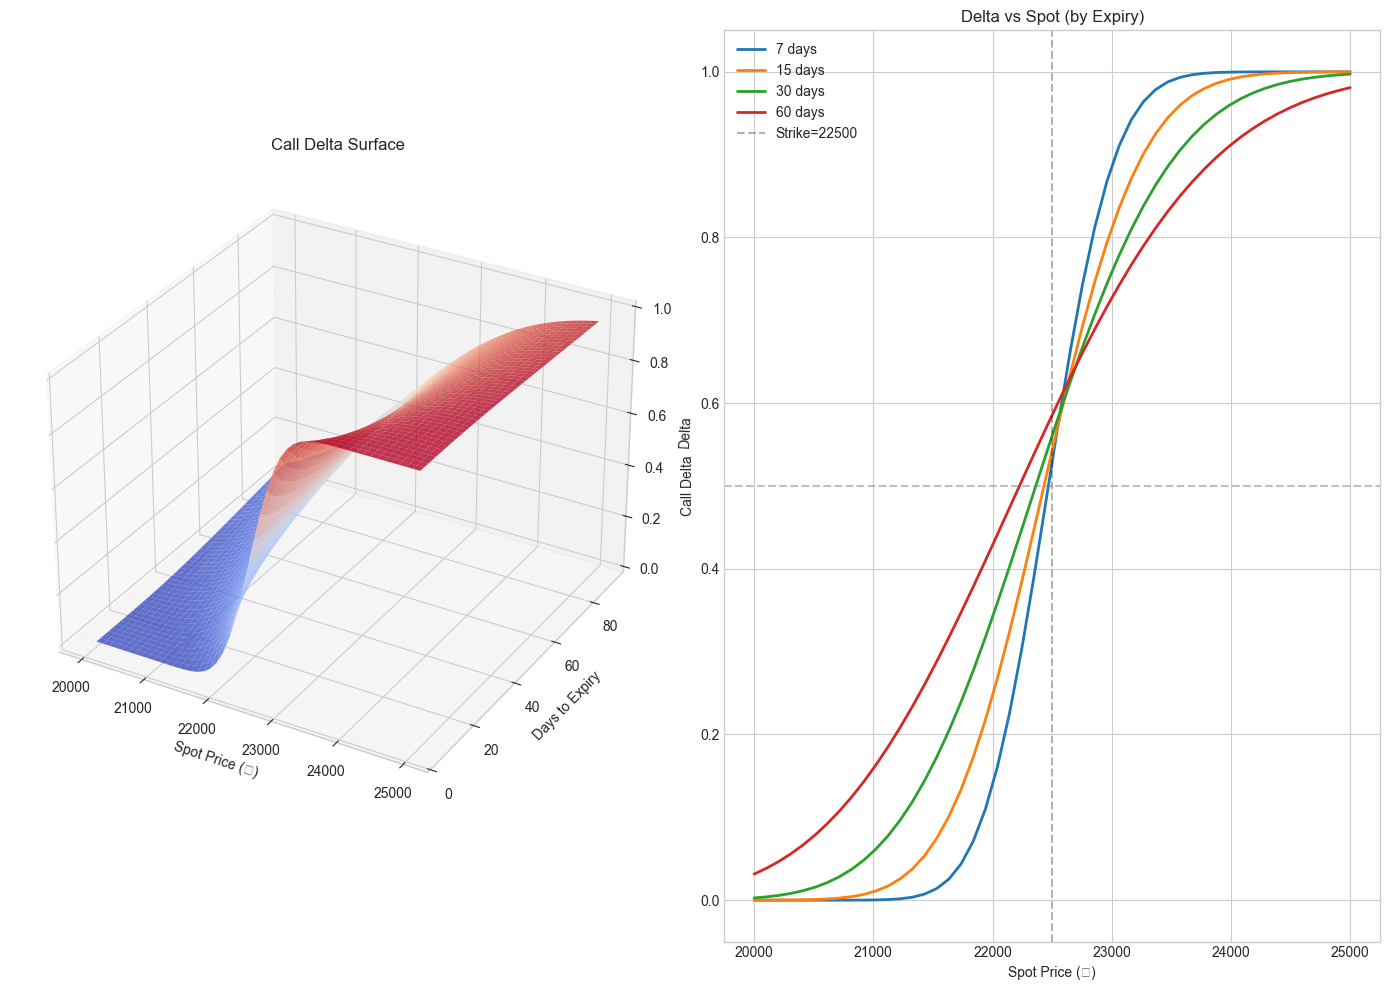

In [11]:
# Create grid for visualization
spots = np.linspace(20000, 25000, 50)
expiries = np.linspace(5/365, 90/365, 50)

S_grid, T_grid = np.meshgrid(spots, expiries)
delta_grid = np.vectorize(lambda s, t: bs.delta(s, K, t, sigma, "call"))(S_grid, T_grid)

fig = plt.figure(figsize=(14, 10))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(S_grid, T_grid * 365, delta_grid, cmap="coolwarm", alpha=0.8)
ax1.set_xlabel("Spot Price (₹)")
ax1.set_ylabel("Days to Expiry")
ax1.set_zlabel("Delta")
ax1.set_title("Call Delta Surface")

# 2D: Delta vs Spot for different expiries
ax2 = fig.add_subplot(122)
for days in [7, 15, 30, 60]:
    t = days / 365
    deltas = [bs.delta(s, K, t, sigma, "call") for s in spots]
    ax2.plot(spots, deltas, label=f"{days} days", lw=2)

ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax2.axvline(K, color="black", linestyle="--", alpha=0.3, label=f"Strike={K}")
ax2.set_xlabel("Spot Price (₹)")
ax2.set_ylabel("Call Delta")
ax2.set_title("Delta vs Spot (by Expiry)")
ax2.legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "delta_surface.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 3 — All Greeks Overview

| Greek | Symbol | Measures | Formula |
|-------|--------|----------|---------|
| Delta | $\Delta$ | Price sensitivity to spot | $\partial C / \partial S$ |
| Gamma | $\Gamma$ | Delta's rate of change | $\partial^2 C / \partial S^2$ |
| Theta | $\Theta$ | Time decay per day | $\partial C / \partial T$ |
| Vega  | $\nu$ | Volatility sensitivity | $\partial C / \partial \sigma$ |
| Rho   | $\rho$ | Interest rate sensitivity | $\partial C / \partial r$ |

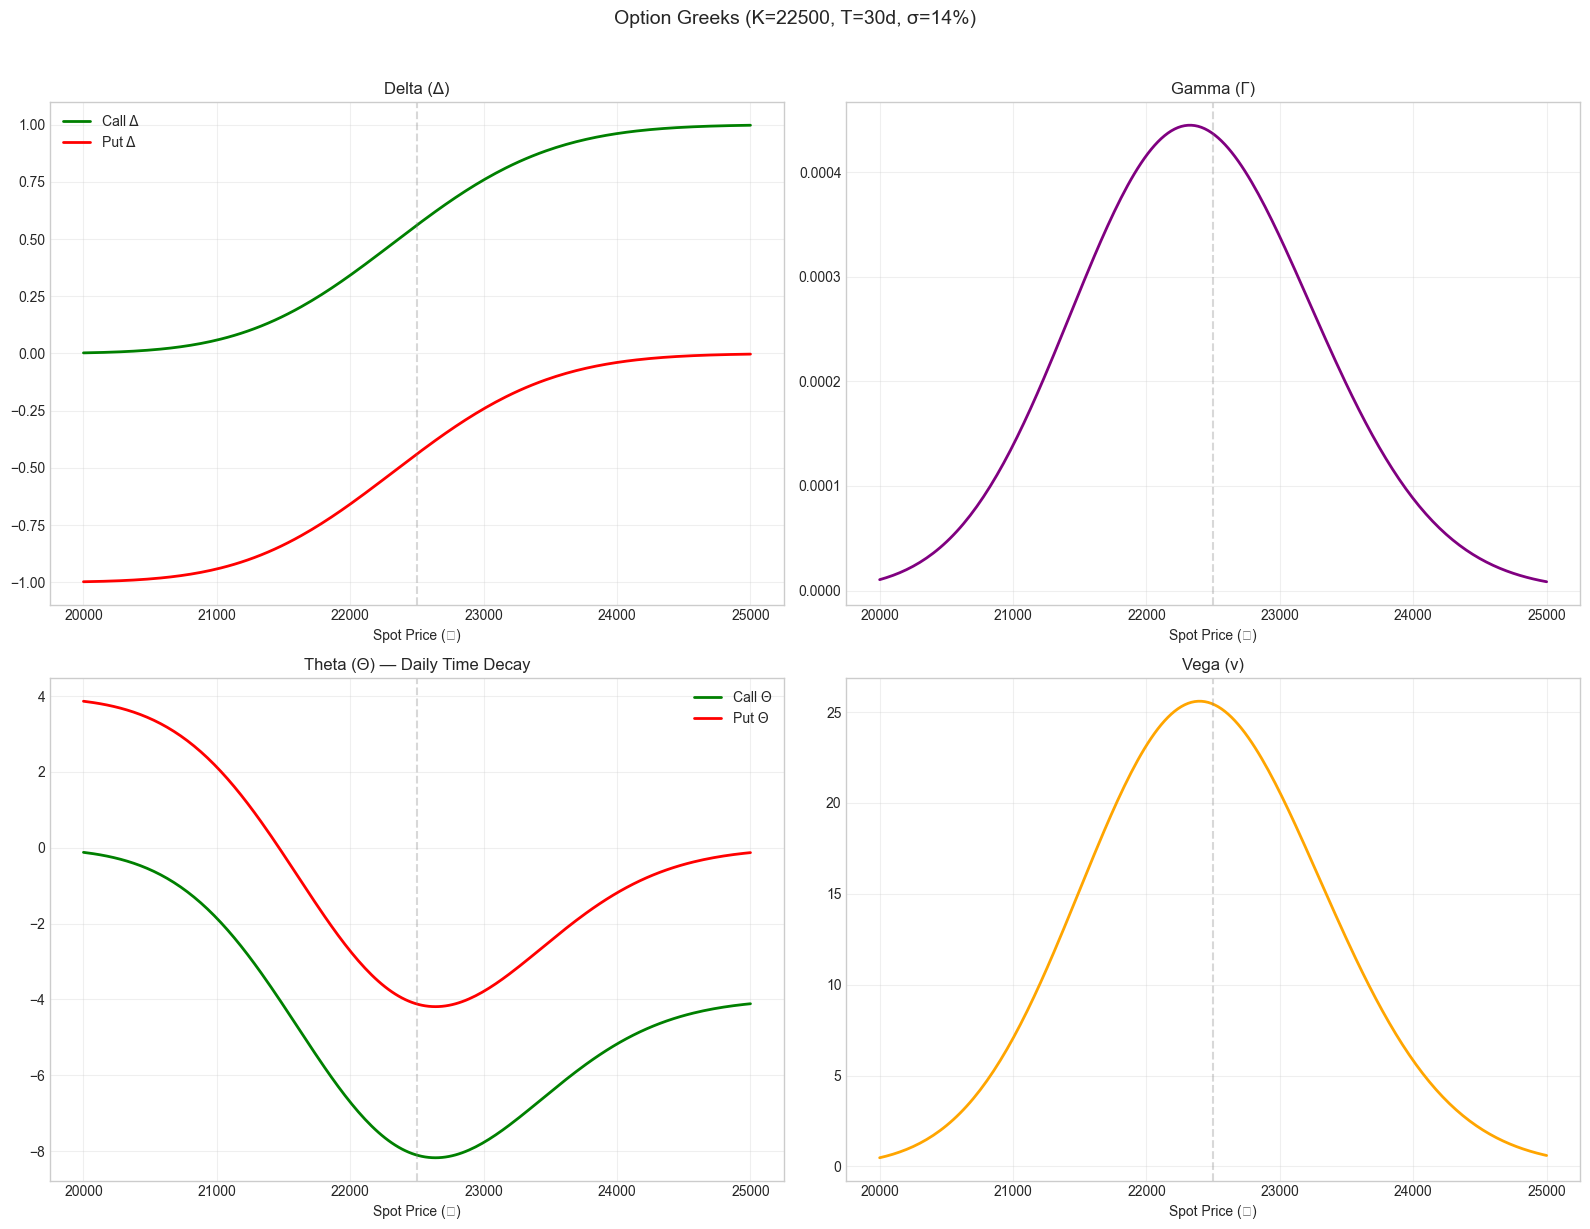

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Range of spot prices
spots = np.linspace(20000, 25000, 200)

# Delta
call_deltas = [bs.delta(s, K, T, sigma, "call") for s in spots]
put_deltas = [bs.delta(s, K, T, sigma, "put") for s in spots]
axes[0, 0].plot(spots, call_deltas, label="Call Δ", color="green", lw=2)
axes[0, 0].plot(spots, put_deltas, label="Put Δ", color="red", lw=2)
axes[0, 0].set_title("Delta (Δ)")
axes[0, 0].legend()
axes[0, 0].axvline(K, color="gray", linestyle="--", alpha=0.3)

# Gamma (same for calls and puts)
gammas = [bs.gamma(s, K, T, sigma) for s in spots]
axes[0, 1].plot(spots, gammas, color="purple", lw=2)
axes[0, 1].set_title("Gamma (Γ)")
axes[0, 1].axvline(K, color="gray", linestyle="--", alpha=0.3)

# Theta
call_thetas = [bs.theta(s, K, T, sigma, "call") for s in spots]
put_thetas = [bs.theta(s, K, T, sigma, "put") for s in spots]
axes[1, 0].plot(spots, call_thetas, label="Call Θ", color="green", lw=2)
axes[1, 0].plot(spots, put_thetas, label="Put Θ", color="red", lw=2)
axes[1, 0].set_title("Theta (Θ) — Daily Time Decay")
axes[1, 0].legend()
axes[1, 0].axvline(K, color="gray", linestyle="--", alpha=0.3)

# Vega (same for calls and puts)
vegas = [bs.vega(s, K, T, sigma) for s in spots]
axes[1, 1].plot(spots, vegas, color="orange", lw=2)
axes[1, 1].set_title("Vega (ν)")
axes[1, 1].axvline(K, color="gray", linestyle="--", alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel("Spot Price (₹)")
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Option Greeks (K={K}, T={T*365:.0f}d, σ={sigma:.0%})", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "greeks_overview.png", dpi=150, bbox_inches="tight")
plt.show()

### Understanding the Greeks — Investment Banking Interpretation

| Greek | Symbol | What It Measures | Typical Range (ATM) | Trading Interpretation |
|-------|--------|-----------------|---------------------|----------------------|
| **Delta** | Δ | Rate of change of option price w.r.t. underlying price | Call: 0.4–0.6, Put: -0.6 to -0.4 | **Hedge ratio**: Delta of 0.5 means for every ₹1 move in Nifty, the call moves ₹0.50. Used for delta-neutral hedging. |
| **Gamma** | Γ | Rate of change of delta w.r.t. underlying price | 0.0001–0.001 | **Convexity risk**: High gamma near ATM and expiry means delta changes rapidly → frequent rebalancing needed. "Gamma scalping" profits from this. |
| **Theta** | Θ | Daily time decay (₹/day) | -5 to -50 for Nifty | **Time cost**: Option sellers earn theta; buyers pay it. ATM options lose ~3x more value in last week vs first week. |
| **Vega** | ν | Sensitivity to 1% change in implied volatility | 10–50 for Nifty | **Vol exposure**: Before earnings/events, vega is key — options gain value as IV rises. After events, "IV crush" causes rapid vega loss. |
| **Rho** | ρ | Sensitivity to 1% change in interest rate | Negligible for short-dated | **Usually ignored** for < 90-day options. Matters for LEAPS and deep ITM options. |

**Key Rules for Groww/Zerodha Traders:**
- **Net delta** tells you market direction exposure (positive = bullish, negative = bearish)
- **Negative gamma** positions (naked short options) have unlimited risk — avoid without hedges
- **Theta-positive** strategies (iron condors, covered calls) profit from time decay but bear gamma risk
- **High vega** before events = potential profit if you're right on direction + magnitude

## Step 4 — Implied Volatility

Given a market price, we back-solve the Black-Scholes formula
to find what volatility the market is implying.

**Method**: Newton-Raphson iteration using Vega as the derivative.

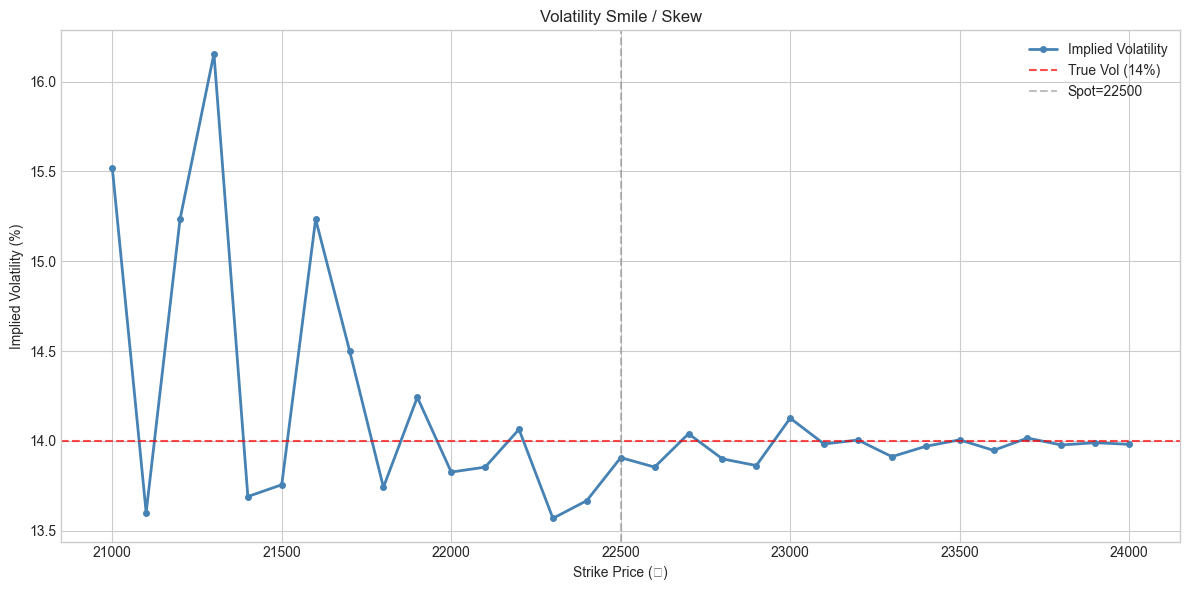


ATM Implied Vol: 13.91%
True Vol: 14.00%


In [12]:
# Simulate market prices for different strikes
strikes = np.arange(21000, 24001, 100)
true_vol = 0.14  # True volatility

# Generate "market" prices with slight noise
np.random.seed(42)
market_calls = [bs.call_price(S, k, T, true_vol) * (1 + np.random.normal(0, 0.01))
                for k in strikes]

# Back out implied volatility
implied_vols = []
for k, price in zip(strikes, market_calls):
    try:
        iv = bs.implied_volatility(price, S, k, T, "call")
        implied_vols.append(iv)
    except:
        implied_vols.append(np.nan)

# Plot the volatility smile
fig, ax = plt.subplots(figsize=(12, 6))
moneyness = S / strikes  # > 1 = ITM calls, < 1 = OTM calls

ax.plot(strikes, [v * 100 for v in implied_vols], 'o-', color="steelblue",
        lw=2, markersize=4, label="Implied Volatility")
ax.axhline(true_vol * 100, color="red", linestyle="--",
           label=f"True Vol ({true_vol:.0%})", alpha=0.7)
ax.axvline(S, color="gray", linestyle="--", alpha=0.5, label=f"Spot={S}")

ax.set_xlabel("Strike Price (₹)")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title("Volatility Smile / Skew")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "vol_smile.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nATM Implied Vol: {implied_vols[len(implied_vols)//2]*100:.2f}%")
print(f"True Vol: {true_vol*100:.2f}%")

## Step 5 — Options Strategy Signals

The signal generator recommends a strategy based on:

| Direction | Confidence | Volatility | Strategy |
|-----------|-----------|------------|----------|
| Bullish | High | Low | Bull Call Spread |
| Bullish | High | High | Protected Covered Call |
| Bearish | High | Low | Bear Put Spread |
| Bearish | High | High | Protective Put |
| Neutral | Any | High | Iron Condor |
| Neutral | Low | High | Long Straddle |

In [13]:
# Generate signals for different market scenarios
scenarios = [
    ("Bullish Nifty (Low Vol)", "NIFTY", S, sigma * 0.8, 0.04, 0.75),
    ("Bullish Nifty (High Vol)", "NIFTY", S, sigma * 1.5, 0.06, 0.80),
    ("Bearish BankNifty (Low Vol)", "BANKNIFTY", 48000, 0.16, -0.03, 0.70),
    ("Bearish BankNifty (High Vol)", "BANKNIFTY", 48000, 0.25, -0.05, 0.75),
    ("Neutral Nifty (High Vol)", "NIFTY", S, sigma * 1.8, 0.001, 0.50),
    ("Neutral Low Confidence", "NIFTY", S, sigma * 2.0, -0.002, 0.45),
]

print("╔══════════════ OPTIONS STRATEGY SIGNALS ══════════════╗\n")

for name, underlying, spot, vol, pred_ret, conf in scenarios:
    signal = sig_gen.generate_signal(
        underlying=underlying,
        spot=spot,
        pred_return=pred_ret,
        confidence=conf,
        hist_vol=sigma,
        implied_vol=vol,
        days_to_expiry=30
    )
    
    formatted = sig_gen.format_signal(signal)
    print(f"━━━ Scenario: {name} ━━━")
    print(formatted)
    print()

╔══════════════ OPTIONS STRATEGY SIGNALS ══════════════╗

━━━ Scenario: Bullish Nifty (Low Vol) ━━━
╔══════════════ Options Signal: NIFTY ══════════════╗
  Strategy:   Bull Call Spread
  Direction:  BULLISH
  Confidence: 75.0%

  Legs:
    BUY  CE @ 22,500  (₹422.41)
    SELL CE @ 22,600  (₹370.39)

  Max Profit:  ₹1,199 (48 per lot unit)
  Max Loss:    ₹1,301 (net debit 52)
  Breakeven:   22552

  ATM Greeks:  Δ=0.561  Γ=0.00044  Θ=-8.107  V=25.434

  Rationale: Model predicts +4.00% move with 75% confidence. Historical vol 14.0% vs implied 11.2% (ratio 1.25). Selected Bull Call Spread strategy.
╚═══════════════════════════════════════════════════════╝

━━━ Scenario: Bullish Nifty (High Vol) ━━━
╔══════════════ Options Signal: NIFTY ══════════════╗
  Strategy:   Bull Call Spread
  Direction:  BULLISH
  Confidence: 80.0%

  Legs:
    BUY  CE @ 22,500  (₹422.41)
    SELL CE @ 22,600  (₹370.39)

  Max Profit:  ₹1,199 (48 per lot unit)
  Max Loss:    ₹1,301 (net debit 52)
  Breakeven:   2

## Step 6 — Strategy P&L Payoff Diagrams

Visualize the profit/loss at expiry for each strategy.

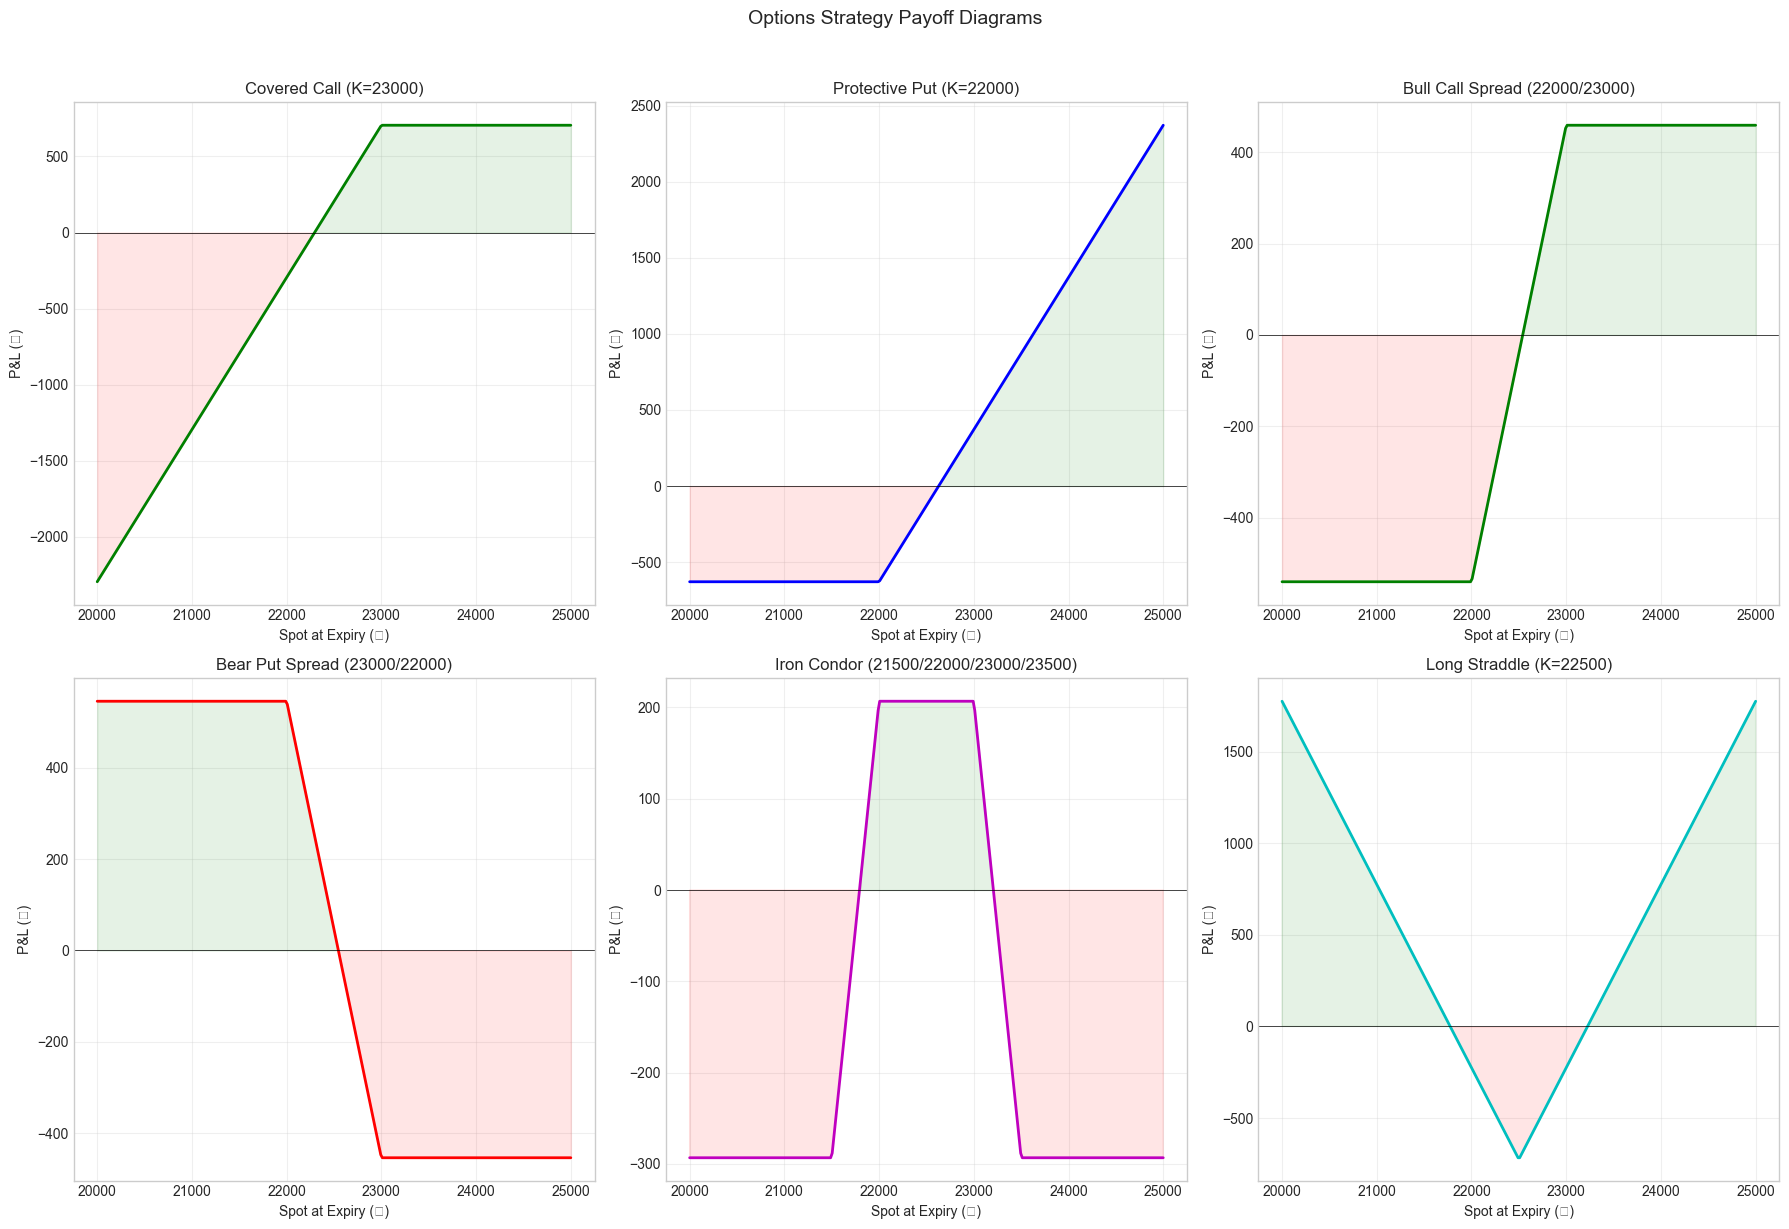

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
spot_range = np.linspace(20000, 25000, 300)

# 1. Covered Call: Long stock + Short call
K_cc = 23000
premium_cc = bs.call_price(S, K_cc, T, sigma)
pnl_cc = (spot_range - S) + premium_cc - np.maximum(spot_range - K_cc, 0)
axes[0, 0].plot(spot_range, pnl_cc, 'g-', lw=2)
axes[0, 0].axhline(0, color='black', lw=0.5)
axes[0, 0].fill_between(spot_range, pnl_cc, 0, where=pnl_cc > 0, alpha=0.1, color='green')
axes[0, 0].fill_between(spot_range, pnl_cc, 0, where=pnl_cc < 0, alpha=0.1, color='red')
axes[0, 0].set_title(f"Covered Call (K={K_cc})")

# 2. Protective Put: Long stock + Long put
K_pp = 22000
premium_pp = bs.put_price(S, K_pp, T, sigma)
pnl_pp = (spot_range - S) + np.maximum(K_pp - spot_range, 0) - premium_pp
axes[0, 1].plot(spot_range, pnl_pp, 'b-', lw=2)
axes[0, 1].axhline(0, color='black', lw=0.5)
axes[0, 1].fill_between(spot_range, pnl_pp, 0, where=pnl_pp > 0, alpha=0.1, color='green')
axes[0, 1].fill_between(spot_range, pnl_pp, 0, where=pnl_pp < 0, alpha=0.1, color='red')
axes[0, 1].set_title(f"Protective Put (K={K_pp})")

# 3. Bull Call Spread: Long call (lower K) + Short call (higher K)
K_low, K_high = 22000, 23000
p_low = bs.call_price(S, K_low, T, sigma)
p_high = bs.call_price(S, K_high, T, sigma)
pnl_bcs = np.maximum(spot_range - K_low, 0) - np.maximum(spot_range - K_high, 0) - (p_low - p_high)
axes[0, 2].plot(spot_range, pnl_bcs, 'g-', lw=2)
axes[0, 2].axhline(0, color='black', lw=0.5)
axes[0, 2].fill_between(spot_range, pnl_bcs, 0, where=pnl_bcs > 0, alpha=0.1, color='green')
axes[0, 2].fill_between(spot_range, pnl_bcs, 0, where=pnl_bcs < 0, alpha=0.1, color='red')
axes[0, 2].set_title(f"Bull Call Spread ({K_low}/{K_high})")

# 4. Bear Put Spread: Long put (higher K) + Short put (lower K)
p_put_high = bs.put_price(S, K_high, T, sigma)
p_put_low = bs.put_price(S, K_low, T, sigma)
pnl_bps = np.maximum(K_high - spot_range, 0) - np.maximum(K_low - spot_range, 0) - (p_put_high - p_put_low)
axes[1, 0].plot(spot_range, pnl_bps, 'r-', lw=2)
axes[1, 0].axhline(0, color='black', lw=0.5)
axes[1, 0].fill_between(spot_range, pnl_bps, 0, where=pnl_bps > 0, alpha=0.1, color='green')
axes[1, 0].fill_between(spot_range, pnl_bps, 0, where=pnl_bps < 0, alpha=0.1, color='red')
axes[1, 0].set_title(f"Bear Put Spread ({K_high}/{K_low})")

# 5. Iron Condor: Bull put spread + Bear call spread
K1, K2, K3, K4 = 21500, 22000, 23000, 23500
ic_credit = (bs.put_price(S, K2, T, sigma) - bs.put_price(S, K1, T, sigma) +
             bs.call_price(S, K3, T, sigma) - bs.call_price(S, K4, T, sigma))
pnl_ic = ic_credit - np.maximum(K2 - spot_range, 0) + np.maximum(K1 - spot_range, 0) - np.maximum(spot_range - K3, 0) + np.maximum(spot_range - K4, 0)
axes[1, 1].plot(spot_range, pnl_ic, 'm-', lw=2)
axes[1, 1].axhline(0, color='black', lw=0.5)
axes[1, 1].fill_between(spot_range, pnl_ic, 0, where=pnl_ic > 0, alpha=0.1, color='green')
axes[1, 1].fill_between(spot_range, pnl_ic, 0, where=pnl_ic < 0, alpha=0.1, color='red')
axes[1, 1].set_title(f"Iron Condor ({K1}/{K2}/{K3}/{K4})")

# 6. Long Straddle: Long call + Long put (same strike)
c_atm = bs.call_price(S, K, T, sigma)
p_atm = bs.put_price(S, K, T, sigma)
pnl_straddle = np.maximum(spot_range - K, 0) + np.maximum(K - spot_range, 0) - c_atm - p_atm
axes[1, 2].plot(spot_range, pnl_straddle, 'c-', lw=2)
axes[1, 2].axhline(0, color='black', lw=0.5)
axes[1, 2].fill_between(spot_range, pnl_straddle, 0, where=pnl_straddle > 0, alpha=0.1, color='green')
axes[1, 2].fill_between(spot_range, pnl_straddle, 0, where=pnl_straddle < 0, alpha=0.1, color='red')
axes[1, 2].set_title(f"Long Straddle (K={K})")

for ax in axes.flat:
    ax.set_xlabel("Spot at Expiry (₹)")
    ax.set_ylabel("P&L (₹)")
    ax.grid(True, alpha=0.3)

plt.suptitle("Options Strategy Payoff Diagrams", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "options_payoffs.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7 — Theta Decay Visualization

Time decay accelerates as expiry approaches. This is critical for
option sellers (covered calls, iron condors) vs buyers (straddles).

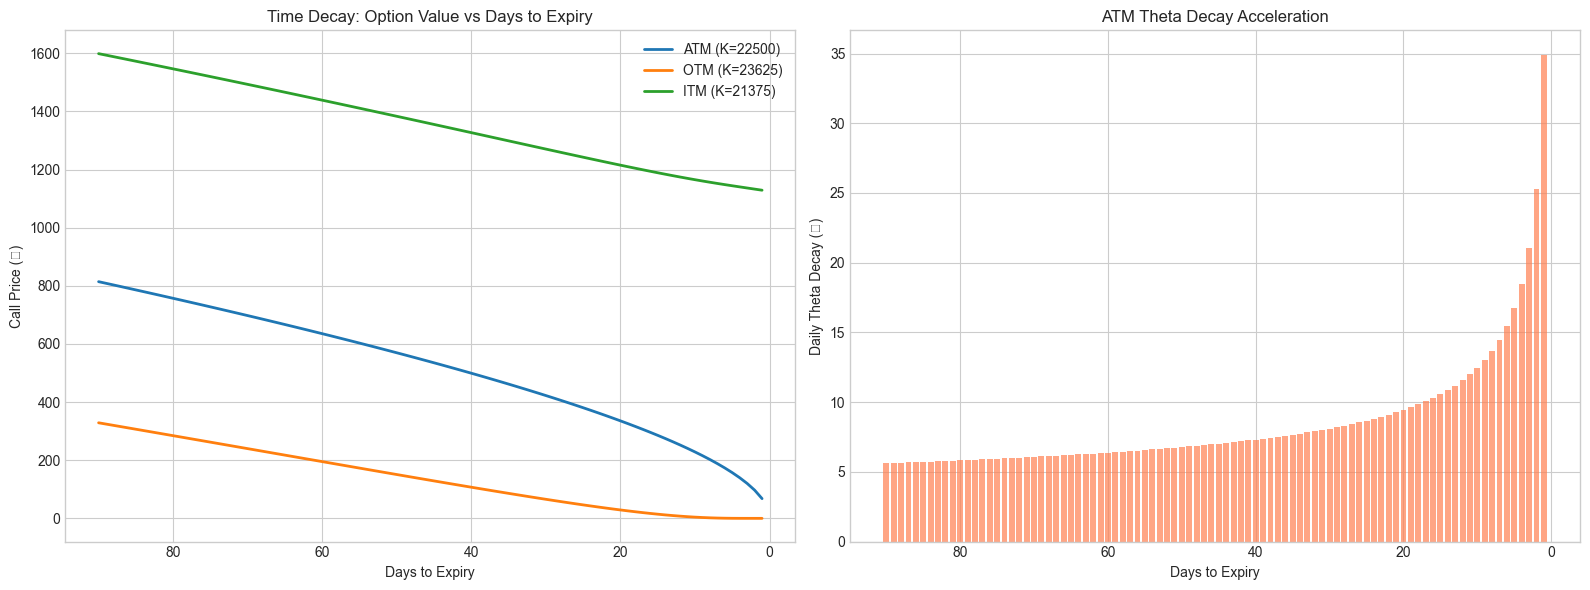


Theta at 30 days: ₹8.11/day
Theta at 7 days:  ₹14.48/day
Theta at 1 day:   ₹34.91/day

⚠️ Note: Theta decay accelerates ~3x in the last week!


In [15]:
days_range = np.arange(1, 91)
atm_values = [bs.call_price(S, K, d/365, sigma) for d in days_range]
otm_values = [bs.call_price(S, K * 1.05, d/365, sigma) for d in days_range]
itm_values = [bs.call_price(S, K * 0.95, d/365, sigma) for d in days_range]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Option value vs time
axes[0].plot(days_range, atm_values, label="ATM (K=22500)", lw=2)
axes[0].plot(days_range, otm_values, label="OTM (K=23625)", lw=2)
axes[0].plot(days_range, itm_values, label="ITM (K=21375)", lw=2)
axes[0].set_xlabel("Days to Expiry")
axes[0].set_ylabel("Call Price (₹)")
axes[0].set_title("Time Decay: Option Value vs Days to Expiry")
axes[0].legend()
axes[0].invert_xaxis()

# Daily theta decay
atm_thetas = [-bs.theta(S, K, d/365, sigma, "call") for d in days_range]
axes[1].bar(days_range, atm_thetas, color="coral", alpha=0.7)
axes[1].set_xlabel("Days to Expiry")
axes[1].set_ylabel("Daily Theta Decay (₹)")
axes[1].set_title("ATM Theta Decay Acceleration")
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "theta_decay.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTheta at 30 days: ₹{-bs.theta(S, K, 30/365, sigma, 'call'):.2f}/day")
print(f"Theta at 7 days:  ₹{-bs.theta(S, K, 7/365, sigma, 'call'):.2f}/day")
print(f"Theta at 1 day:   ₹{-bs.theta(S, K, 1/365, sigma, 'call'):.2f}/day")
print("\n⚠️ Note: Theta decay accelerates ~3x in the last week!")

## ✅ Options Lab Complete!

**What you learned:**
- Black-Scholes option pricing with put-call parity
- All 5 Greeks visualized (Delta, Gamma, Theta, Vega, Rho)
- Implied volatility via Newton-Raphson
- 6 options strategies with payoff diagrams
- Time decay acceleration near expiry

**Next:** Proceed to **Notebook 14 — Final Report & Conclusions**

---
*Educational project. Not financial advice.*